In [1]:
library(tidyverse)
library(lme4)
library(lmerTest)
library(broom)
library(broom.mixed)
library(ggeffects)
library(emmeans)
library(performance)
library(patchwork)
library(cowplot)
library(modelsummary)
library(datawizard)

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.5
v forcats   1.0.0     v stringr   1.5.2
v ggplot2   3.5.2     v tibble    3.3.0
v lubridate 1.9.4     v tidyr     1.3.1
v purrr     1.1.0     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack



Attaching package: 'lmerTest'


The following object is masked from 'package:lme4':

    lmer


The following object is masked from 'package:stats':

    step


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'


Attaching package: 'cowplot'


The following object

In [20]:
df1 <- data.frame(
  IR_Metric = c("TYG", "TYG-BMI", "METS-IR", "TG/HDL", "GSK3A", "GSK3B", "Insulin"),
  AB        = c(23.69, 66.76, 72.33, 27.50, -34.94, -55.73, 40.13),
  AB_CI_LL  = c(0.73, -12.79, 4.21, 3.33, -71.27, -92.98, 0.88),
  AB_CI_UL  = c(46.67, 146.30, 140.47, 51.68, 1.40, -18.42, 79.37),
  TAU       = c(-5.34, -10.56, -16.44, -7.15, -16.32, -41.50, 15.95),
  TAU_CI_LL = c(-13.81, -39.13, -40.95, -16.06, -30.44, -55.46, 0.63),
  TAU_CI_UL = c(3.15, 18.07, 8.13, 1.78, -2.21, -27.54, 31.25),
  PTAU      = c(-0.75, -1.68, -2.19, -0.95, -1.70, -4.49, 1.57),
  PTAU_CI_LL= c(-1.67, -4.82, -4.88, -1.93, -3.24, -6.01, -0.09),
  PTAU_CI_UL= c(0.18, 1.47, 0.51, 0.02, -0.17, -2.97, 3.24),
  stringsAsFactors = FALSE
)

In [21]:
class(df1)
str(df1)

[1] "data.frame"

'data.frame':	7 obs. of  10 variables:
 $ IR_Metric : chr  "TYG" "TYG-BMI" "METS-IR" "TG/HDL" ...
 $ AB        : num  23.7 66.8 72.3 27.5 -34.9 ...
 $ AB_CI_LL  : num  0.73 -12.79 4.21 3.33 -71.27 ...
 $ AB_CI_UL  : num  46.7 146.3 140.5 51.7 1.4 ...
 $ TAU       : num  -5.34 -10.56 -16.44 -7.15 -16.32 ...
 $ TAU_CI_LL : num  -13.8 -39.1 -41 -16.1 -30.4 ...
 $ TAU_CI_UL : num  3.15 18.07 8.13 1.78 -2.21 ...
 $ PTAU      : num  -0.75 -1.68 -2.19 -0.95 -1.7 -4.49 1.57
 $ PTAU_CI_LL: num  -1.67 -4.82 -4.88 -1.93 -3.24 -6.01 -0.09
 $ PTAU_CI_UL: num  0.18 1.47 0.51 0.02 -0.17 -2.97 3.24


In [25]:
library(dplyr)
library(tidyr)

long_df1 <- df1 %>%
  pivot_longer(
    cols = -IR_Metric,
    names_to = c("marker", "stat"),
    names_pattern = "^(.*?)(?:_(CI_LL|CI_UL))?$"
  ) %>%
  mutate(stat = ifelse(stat == "", "estimate", stat)) %>%
  pivot_wider(
    names_from = stat,
    values_from = value
  )

In [26]:
long_df1

IR_Metric,marker,estimate,CI_LL,CI_UL
<chr>,<chr>,<dbl>,<dbl>,<dbl>
TYG,AB,23.69,0.73,46.67
TYG,TAU,-5.34,-13.81,3.15
TYG,PTAU,-0.75,-1.67,0.18
TYG-BMI,AB,66.76,-12.79,146.30
TYG-BMI,TAU,-10.56,-39.13,18.07
TYG-BMI,PTAU,-1.68,-4.82,1.47
METS-IR,AB,72.33,4.21,140.47
METS-IR,TAU,-16.44,-40.95,8.13
METS-IR,PTAU,-2.19,-4.88,0.51


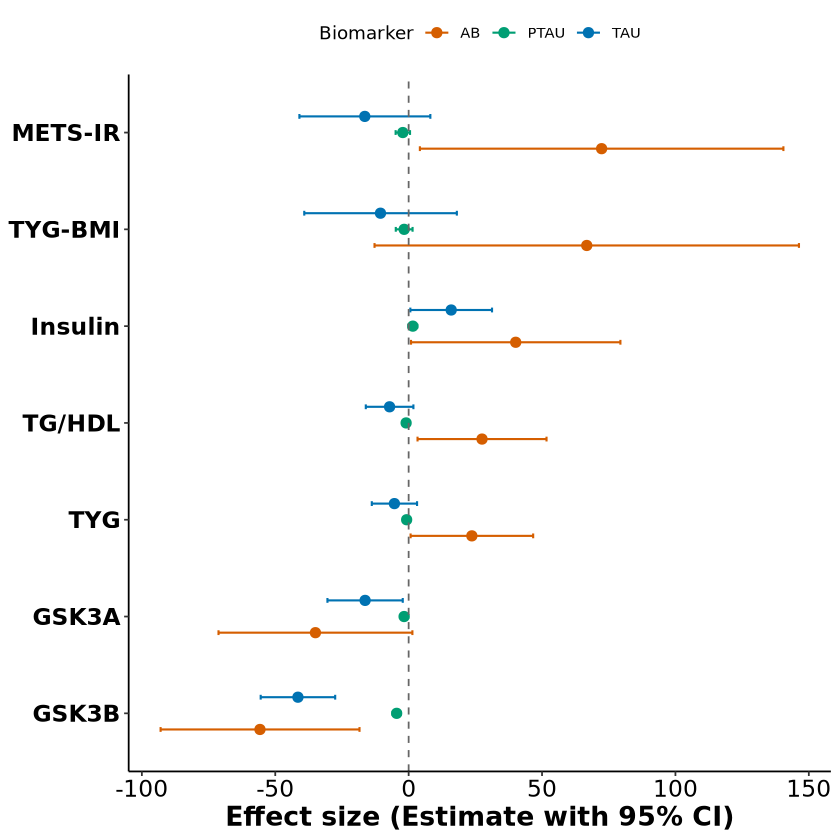

In [29]:
long_df1 <- long_df1 %>%
  group_by(IR_Metric) %>%
  mutate(order_val = estimate[marker == "AB"][1]) %>%
  ungroup() %>%
  mutate(IR_Metric = reorder(IR_Metric, order_val))

p1 <- ggplot(long_df1, aes(x = estimate, y = IR_Metric, color = marker)) +
  geom_point(position = position_dodge(width = 0.5), size = 2.5) +
  geom_errorbarh(
    aes(xmin = CI_LL, xmax = CI_UL),
    position = position_dodge(width = 0.5),
    height = 0.15,
    linewidth = 0.6
  ) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey40") +
  scale_color_manual(
    values = c(
      "AB" = "#D55E00",
      "TAU" = "#0072B2",
      "PTAU" = "#009E73"
    )
  ) +
  labs(
    x = "Effect size (Estimate with 95% CI)",
    y = NULL,
    color = "Biomarker"
  ) +
  theme_classic() +
  theme(
    legend.position = "top",
    axis.text.x = element_text(size = 14, color = "black"),
    axis.text.y = element_text(size = 14, color = "black", face = "bold"),
    axis.title.x = element_text(size = 16, color = "black", face = "bold"),
    axis.title.y = element_text(size = 16, color = "black")
  )

p1

In [30]:
ggsave(
  "forest_plot_agg.png",
  p1,
  width = 8,
  height = 5,
  dpi = 300
)